In [1]:
from splinetlsm.datasets import load_polecat

from splinetlsm.svi import SplineDynamicLSM
from splinetlsm.mcmc import dynamic_adjacency_to_vec

In [2]:
Y, time_points, X, node_names, iso_codes, regions, time_labels = load_polecat()

In [ ]:
# fit model on all the time points
model_all = SplineDynamicLSM(n_features=6, n_knots_scale_factor=4)
model_all.fit(Y, time_points, X=X)

In [36]:
# randomly subsample 150 observations
rng = np.random.RandomState(42)
subsample = np.sort(rng.choice(time_points, size=150, replace=False))

Y_sub = Y[subsample]
X_sub = X[subsample]
time_points_sub = time_points[subsample]

In [5]:
# fit the model on the subset of observations
model = SplineDynamicLSM(n_features=6, n_knots_scale_factor=4)
model.fit(Y_sub, time_points_sub, X=X_sub)

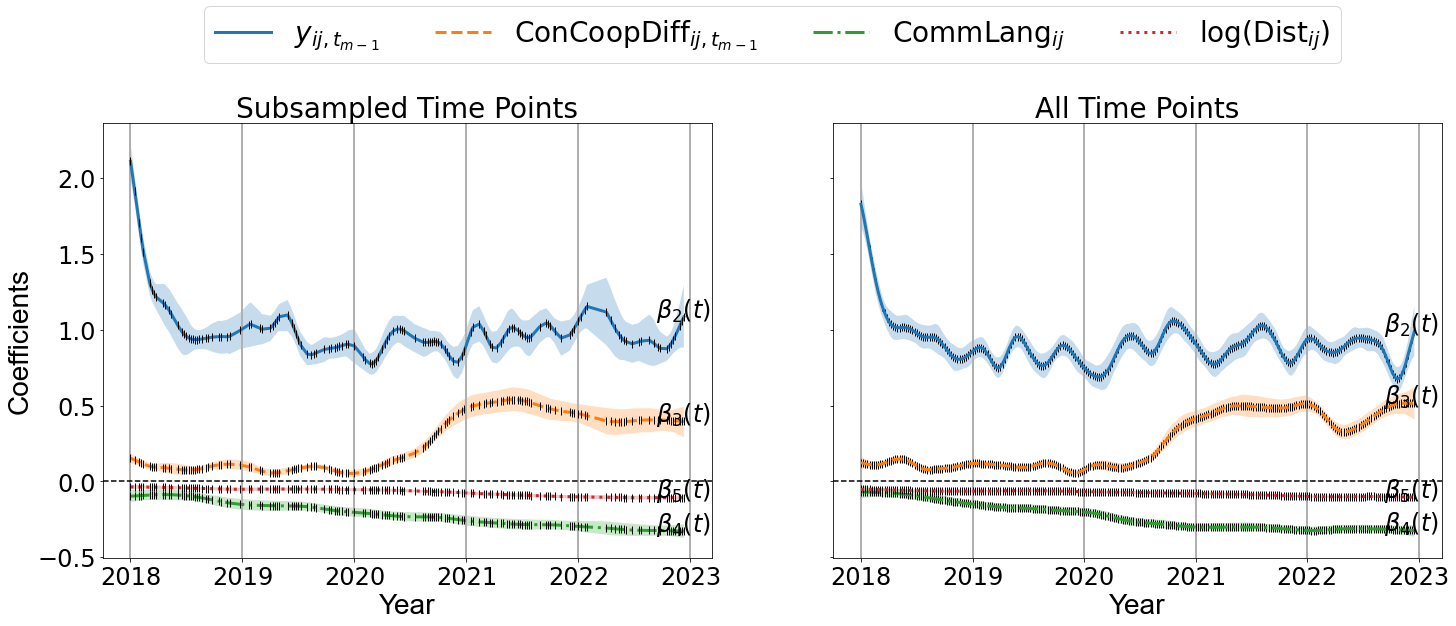

In [40]:
fig, ax = plt.subplots(figsize=(24,8), ncols=2, sharey=True)

labels = [ 
    r"$y_{ij,t_{m-1}}$",
    r"ConCoopDiff$_{ij,t_{m-1}}$",
    r'CommLang$_{ij}$',
    r'$\log($Dist$_{ij})$']

ls = ['-', '--', '-.', ':']

# plot coefficients of subsampled model
coefs = model.samples_['W_coefs'] @ model.B_fit_.todense()
coefs = coefs.transpose((0, 2, 1))
ci = np.quantile(coefs, q=[0.025, 0.5, 0.975], axis=0)
for k in range(X.shape[-1]):
    ax[0].plot(time_points_sub, ci[1, :, k], linestyle=ls[k], lw=3, label=labels[k])
    ax[0].fill_between(time_points_sub, ci[0, :, k], ci[2, :, k], alpha=0.25)
    if k >= 0:
        ax[0].plot(time_points_sub, ci[1, :, k], '|', color='k', markersize=8)
    ax[0].annotate(r"$\beta_{" + str(k+2) + r"}(t)$", 
                (time_points.shape[0]-15, ci[1, -1, k]), fontsize=24)
ax[0].axhline(0, linestyle='--', color='k')

ax[0].set_xticks([i * 52 for i in range(6)])
ax[0].set_xticklabels([2018 + i for i in range(6)], fontsize=24)
ax[0].tick_params(axis='both', which='major', labelsize=24)
ax[0].grid(axis='x', lw=2)
ax[0].set_xlabel('Year', fontsize=28, fontfamily='Arial')
ax[0].set_ylabel('Coefficients', fontsize=28, fontfamily='arial')
ax[0].set_title('Subsampled Time Points', fontsize=28)


# plot coefficients of full model
coefs = model_all.samples_['W_coefs'] @ model_all.B_fit_.todense()
coefs = coefs.transpose((0, 2, 1))
ci = np.quantile(coefs, q=[0.025, 0.5, 0.975], axis=0)

for k in range(X.shape[-1]):
    if k >= 0:
        ax[1].plot(time_points, ci[1, :, k], '|', color='k', markersize=8)
    ax[1].plot(time_points, ci[1, :, k], linestyle=ls[k], lw=3, label=labels[k])
    ax[1].fill_between(time_points, ci[0, :, k], ci[2, :, k], alpha=0.25)
    ax[1].annotate(r"$\beta_{" + str(k+2) + r"}(t)$", 
                (ci.shape[1]-15, ci[1, -1, k]), fontsize=24)
ax[1].axhline(0, linestyle='--', color='k')

ax[1].set_title('All Time Points', fontsize=28)
ax[1].set_xticks([i * 52 for i in range(6)])
ax[1].set_xticklabels([2018 + i for i in range(6)], fontsize=24)
ax[1].tick_params(axis='both', which='major', labelsize=24)
ax[1].grid(axis='x', lw=2)
ax[1].set_xlabel('Year', fontsize=28, fontfamily='Arial')
ax[1].legend(loc='upper center', ncols=4, fontsize=28, bbox_to_anchor=(-0.1, 1.3))